# Лабораторна робота №1
## Інтелектуальний аналіз даних та моделювання кризових явищ
**Тема:** Web Scraping, Data Collection, Visualization.

Розв’язано шість пунктів оригінального `assignement-1.ipynb`. Англомовні умови нижче збережені. Реалізації функцій містяться у [lab1.py](lab1.py), результати виконання — безпосередньо в цьому ноутбуці.

Матеріали з лінійної алгебри та NumPy є теоретичним доповненням. Окремого завдання з моделювання криз у наданому шаблоні немає. ПІБ та групу не задано.

### Запуск
Встановити залежності: `python -m pip install -r requirements.txt`. Відкрити цей ноутбук у Jupyter або VS Code та виконати **Run All**. Робоча папка — корінь репозиторію. Перші два пункти потребують інтернету. Оригінальний CSV Kaggle збережено локально, повторний аналіз не вимагає входу в Kaggle. Мережеві помилки не приховуються.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image
from lab1 import (ROOT, FEATURES, parse_web_page, parse_api, parse_json, parse_csv,
                  read_weather, visualize_weather, load_dataset, impute_data,
                  normalize_data, run_data_experiment, collect_examples)

print("Робоча папка:", ROOT.name)

Робоча папка: ida-labs


## Extract webpage data given the url

Create a Python script that performs basic web scraping on a page to extract all the information into text and returns it as a string. String should not contain tags.

### Розв’язання
`requests.get` завантажує статичний HTML із тайм-аутом, `raise_for_status()` перевіряє HTTP-помилки, BeautifulSoup прибирає теги, скрипти, стилі та коментарі. Пробіли нормалізовано, вкладений текст збережено. JavaScript у браузері не виконується. Приклади URL замінено, як дозволяє умова.

In [2]:
sources = collect_examples()
for source in sources[:2]:
    text = (ROOT / "outputs" / source["file"]).read_text(encoding="utf-8")
    print(source["url"], "—", source["characters"], "символів")
    print(text[:255], "\n")

https://example.com/ — 142 символів
Example Domain Example Domain This domain is for use in documentation examples without needing permission. Avoid use in operations. Learn more
 

https://docs.python.org/3/tutorial/index.html — 7116 символів
The Python Tutorial — Python 3.14.7 documentation Theme Auto Light Dark Previous topic Changelog Next topic 1. Whetting Your Appetite This page Report a bug Improve this page Show source Navigation index modules | next | previous | Python » 3.14.7 Documen 



## Get data from the API

Create a python script that performs basic request to API endpoint and saves that data to a JSON file result.json.

### Розв’язання
`collect_examples()` вище викликає `parse_api("https://api.github.com/")`. Відповідь декодується як JSON та записується в `result.json` у UTF-8. Це відкритий API без токена. Нижче читається фактично збережений файл.

In [3]:
api_result = json.loads((ROOT / "result.json").read_text(encoding="utf-8"))
print("Кількість ключів у відповіді:", len(api_result))
display(dict(list(api_result.items())[:5]))

Кількість ключів у відповіді: 33


{'current_user_url': 'https://api.github.com/user',
 'current_user_authorizations_html_url': 'https://github.com/settings/connections/applications{/client_id}',
 'authorizations_url': 'https://api.github.com/authorizations',
 'code_search_url': 'https://api.github.com/search/code?q={query}{&page,per_page,sort,order}',
 'commit_search_url': 'https://api.github.com/search/commits?q={query}{&page,per_page,sort,order}'}

## Parse the json file

Parse the `weather.json` file and return weather data for a specific date, that is given as a parameter. Return the data as an array.

### Розв’язання
Повертається Python-список словників: назви полів зберігають значення показників. Для відсутньої дати — `[]`, для некоректної — `ValueError`. Нормалізація дати дозволяє вводити місяць і день без початкового нуля. JSON містить чотири дні погоди Токіо у серпні 2024 року.

In [4]:
target_date = "2024-8-19"
result_json = parse_json(target_date)
display(result_json)
assert result_json == parse_json("2024-08-19")
assert result_json[0]["max_temperature"] == 30.0

[{'date': '2024-08-19',
  'max_temperature': 30.0,
  'min_temperature': 21.0,
  'precipitation': 5.0,
  'wind_speed': 10.0,
  'humidity': 70,
  'weather_description': 'Light rain'}]

## Parse the csv file

Parse the `weather.csv` file and return weather data for a specific date, that is given as a parameter. Return the data as an array.

### Розв’язання
CSV має іншу структуру та часовий період. Пробіли в заголовках прибрано, числові поля мають числові типи, пропуски у повернутому списку представлені `None`. Місце спостережень у файлі не вказано, тому йому не приписується назва міста з JSON.

In [5]:
target_date = "1997-5-22"
display(parse_csv(target_date))
assert parse_csv("1997-1-1") == parse_csv("1997-01-01")
assert parse_csv("1900-01-01") == []

[{'CET': '1997-05-22',
  'Max TemperatureC': 25.0,
  'Mean TemperatureC': 18.0,
  'Min TemperatureC': 10.0,
  'Dew PointC': 11.0,
  'MeanDew PointC': 8.0,
  'Min DewpointC': 6.0,
  'Max Humidity': 88.0,
  'Mean Humidity': 54.0,
  'Min Humidity': 34.0,
  'Max Sea Level PressurehPa': 1017,
  'Mean Sea Level PressurehPa': 1015,
  'Min Sea Level PressurehPa': 1012,
  'Max VisibilityKm': 10.0,
  'Mean VisibilityKm': 10.0,
  'Min VisibilitykM': 10.0,
  'Max Wind SpeedKm/h': 11,
  'Mean Wind SpeedKm/h': 3,
  'Max Gust SpeedKm/h': None,
  'Precipitationmm': 0.0,
  'CloudCover': 3.0,
  'Events': None,
  'WindDirDegrees': 277}]

## Visualize data

Visualize the weather.csv data using matplotlib. Choose your own approach to data visualization. Save the results (as .png, .webp files etc., your choise) in this repository.

### Розв’язання
Побудовано часовий графік помісячних температур, гістограму, діаграму розсіювання температури та вологості, а також повноту спостережень за роками. Усі зображення збережені у `figures/`. Порожні значення не замінюються нулями. Помісячні середні розраховано лише за наявними значеннями; діапазон min–max на графіку — середні щоденних мінімумів та максимумів, а не абсолютні екстремуми місяця.

Рядків: 6812
Період: 1997-01-01 — 2015-12-31
Пропусків середньої температури: 3
Повторів дат: 0


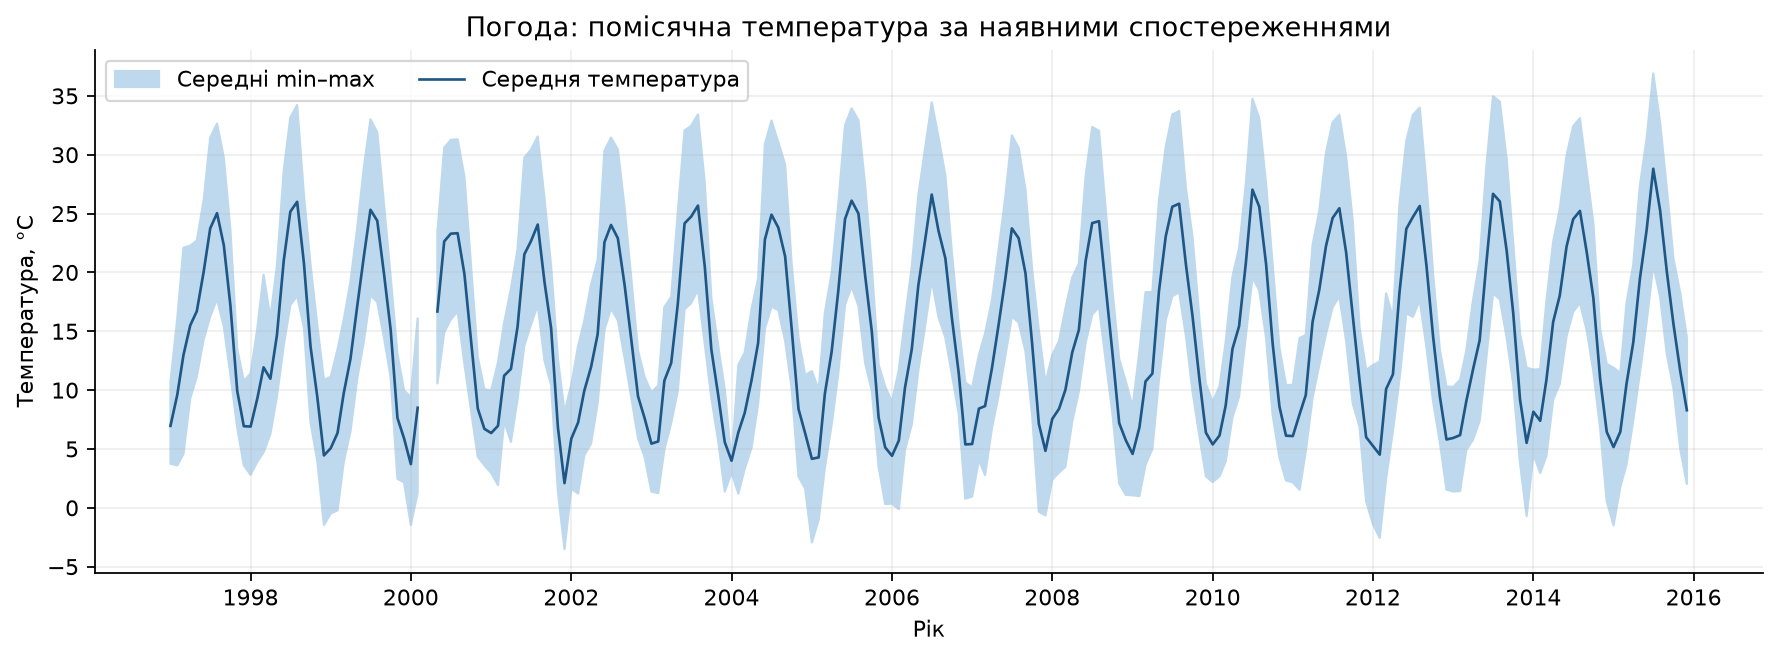

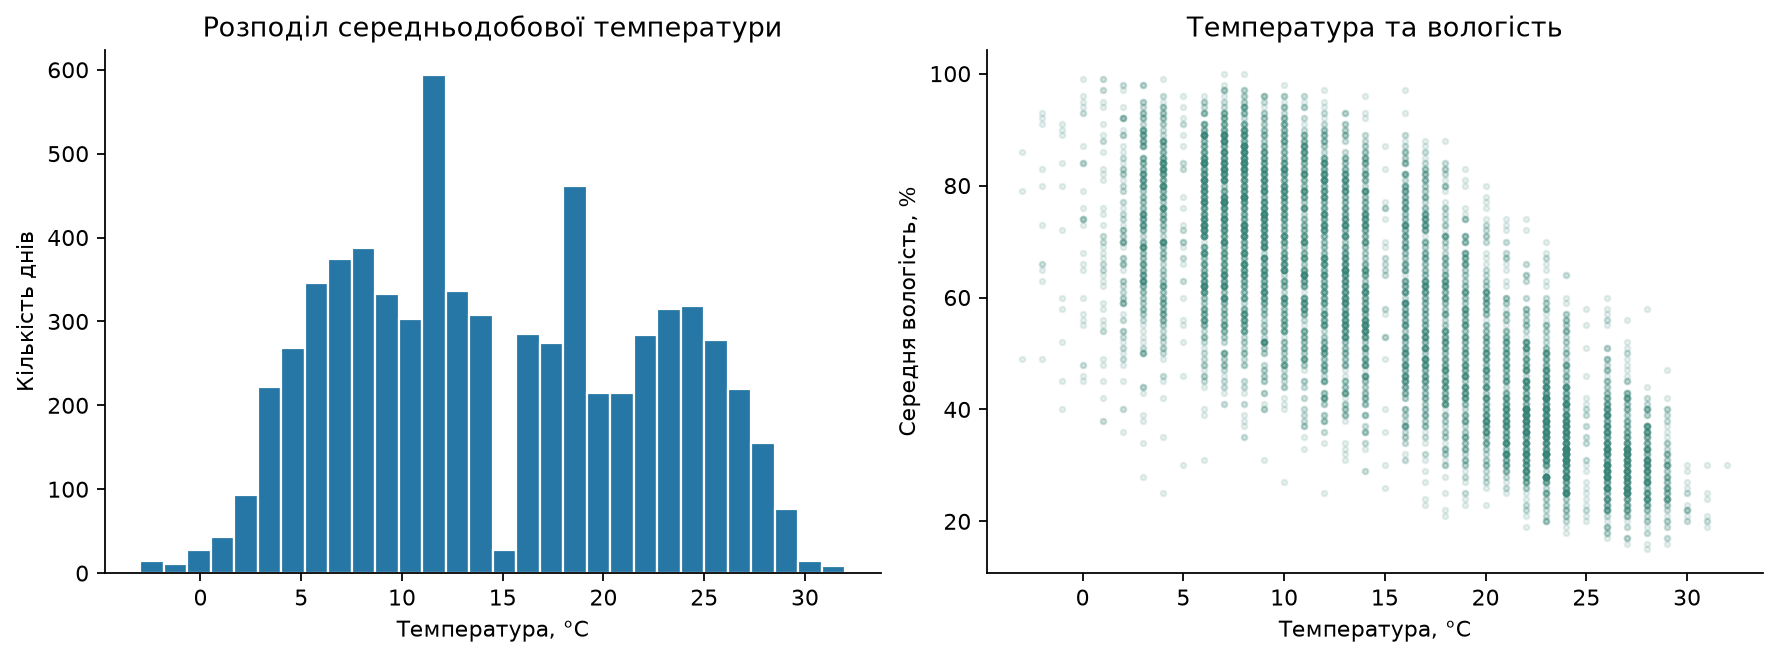

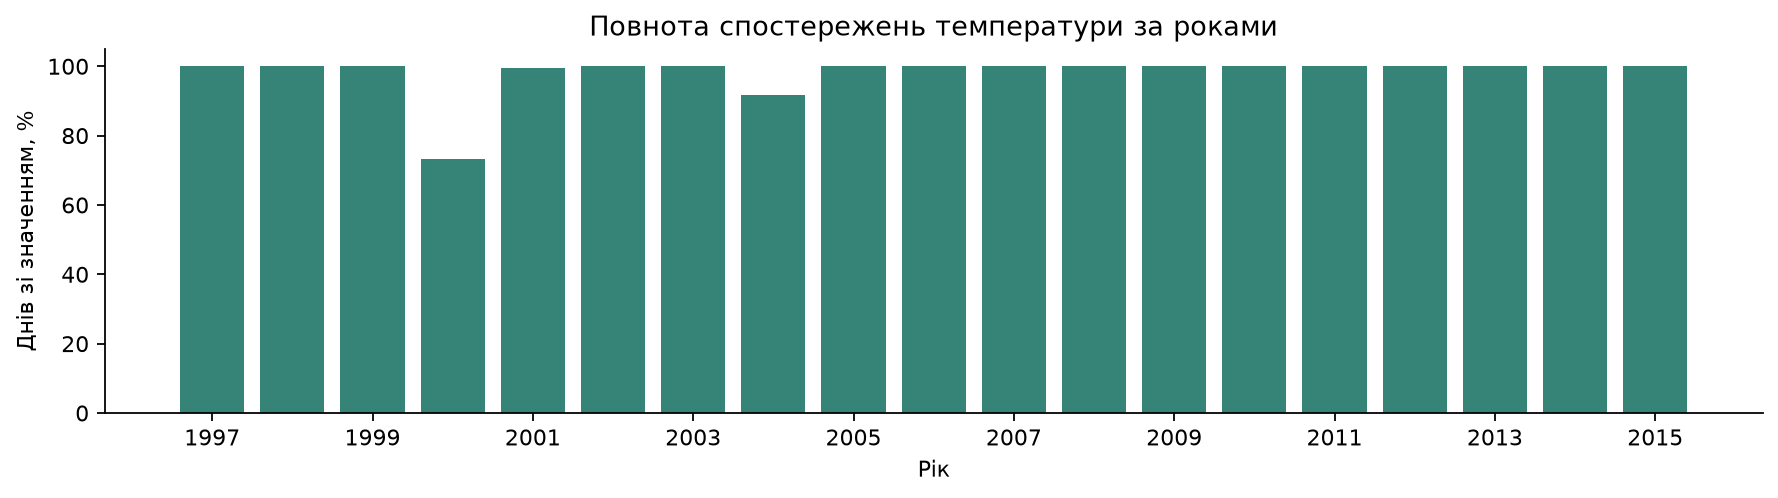

In [6]:
weather = read_weather()
print("Рядків:", len(weather))
print("Період:", weather.CET.min().date(), "—", weather.CET.max().date())
print("Пропусків середньої температури:", int(weather["Mean TemperatureC"].isna().sum()))
print("Повторів дат:", int(weather.CET.duplicated().sum()))
for path in visualize_weather():
    display(Image(filename=str(path)))

In [7]:
monthly_season = weather.groupby(weather.CET.dt.month)["Mean TemperatureC"].mean()
print(f"Найтепліший місяць за всіма наявними спостереженнями: {monthly_season.idxmax()}, середня температура {monthly_season.max():.2f} °C.")
print(f"Найхолодніший місяць: {monthly_season.idxmin()}, середня температура {monthly_season.min():.2f} °C.")
print("Кореляція температури та вологості:", round(weather[["Mean TemperatureC", "Mean Humidity"]].corr().iloc[0, 1], 3))

Найтепліший місяць за всіма наявними спостереженнями: 7, середня температура 25.07 °C.
Найхолодніший місяць: 1, середня температура 5.69 °C.
Кореляція температури та вологості: -0.743


### Інтерпретація
Часовий графік показує сезонність, гістограма — частоту температур, діаграма розсіювання — зв’язок двох показників. Кореляція не встановлює причинність. Різна повнота спостережень може впливати на порівняння років; ці графіки самі по собі не доводять кліматичного тренду або настання кризи.

## Data imputation and normalization.

Download kaggle dataset with incomplete/missing data, and try data imputation techniques (mean, median, mode, knn) on that data. Normalize the data with best option for each dataset (minmax, z-score, robust). Visualize the data (choose your own approach to data visualization).

Dataset options:
- Different Types of Missing Data (by Suryaprabha19) https://www.kaggle.com/datasets/suryaprabha19/different-types-of-missing-data
- Retail Product Dataset with Missing Values (by Himel Sarder) https://www.kaggle.com/datasets/himelsarder/retail-product-dataset-with-missing-values
- Data Cleaning - Feature Imputation (by 
Mr.Machine) https://www.kaggle.com/datasets/ilayaraja07/data-cleaning-feature-imputation
- BI intro to data cleaning eda and machine learning (by Walekhwa Tambiti Leo Philip) https://www.kaggle.com/datasets/walekhwatlphilip/intro-to-data-cleaning-eda-and-machine-learning

### Вибір реальних даних
Використано **Wine_Quality.csv** з рекомендованого набору [Data Cleaning — Feature Imputation](https://www.kaggle.com/datasets/ilayaraja07/data-cleaning-feature-imputation). У запропонованому шаблоном `Students_Performance_knn.csv` є лише 25 пропусків категорії `lunch`; середнє та медіана для неї не визначені. Файл вина з того самого архіву містить числові пропуски, тому дозволяє коректно продемонструвати всі чотири методи. Оригінал збережено у `data/kaggle/`, джерело та SHA-256 — у `data/provenance.json`.

Числові ознаки — 11 фізико-хімічних показників. `type` є категорією, `quality` — порядковою цільовою оцінкою. Їх не використовуємо для обчислення відстаней і не масштабуємо.

In [8]:
df = load_dataset()
print("Розмір:", df.shape)
display(df.head())
display(df.isna().sum().rename("Пропуски"))
display(df[FEATURES].describe())

Розмір: (6497, 13)


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
Name: Пропуски, dtype: int64

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000


### Порівняння методів заповнення
- **Mean:** середнє спостережуваних значень ознаки.
- **Median:** медіана, стійкіша до крайніх значень.
- **Mode:** найчастіше значення; при рівності частот використовується вибір `SimpleImputer`.
- **KNN:** 5 найближчих рядків, ваги обернено пропорційні відстані. Перед пошуком сусідів ознаки стандартизуються, після — повертаються у вихідну шкалу.

Для перевірки 80% рядків виділено на навчання, 20% — на валідацію (`random_state=42`). У перевірочній копії випадково приховано приблизно 10% **відомих** числових значень. Оригінальний CSV не змінюється. Скейлер і заповнювач навчаються лише на навчальній частині. Порівняння виконано за середньою по ознаках MAE, поділеною на стандартне відхилення навчальної ознаки. Менше — краще.

Це один відтворюваний експеримент із випадковим маскуванням. Він не встановлює справжній механізм пропусків і не гарантує такої самої точності на реальних відсутніх значеннях.

method
knn       0.276009
median    0.704591
mean      0.729995
mode      0.743780
Name: Середня стандартизована MAE, dtype: float64

Найменша похибка у цьому експерименті: knn
Реальних пропусків до / після: 38 / 0


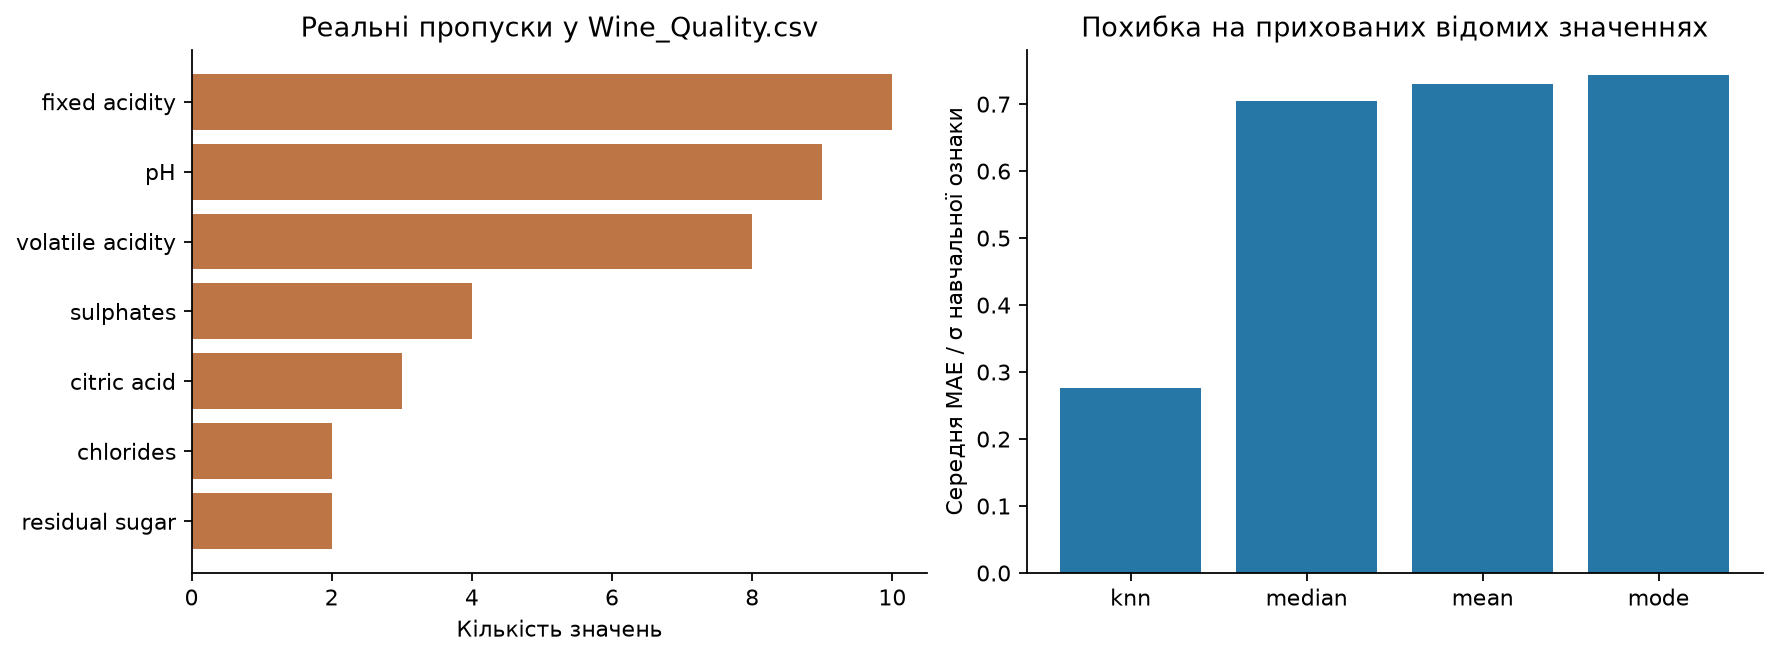

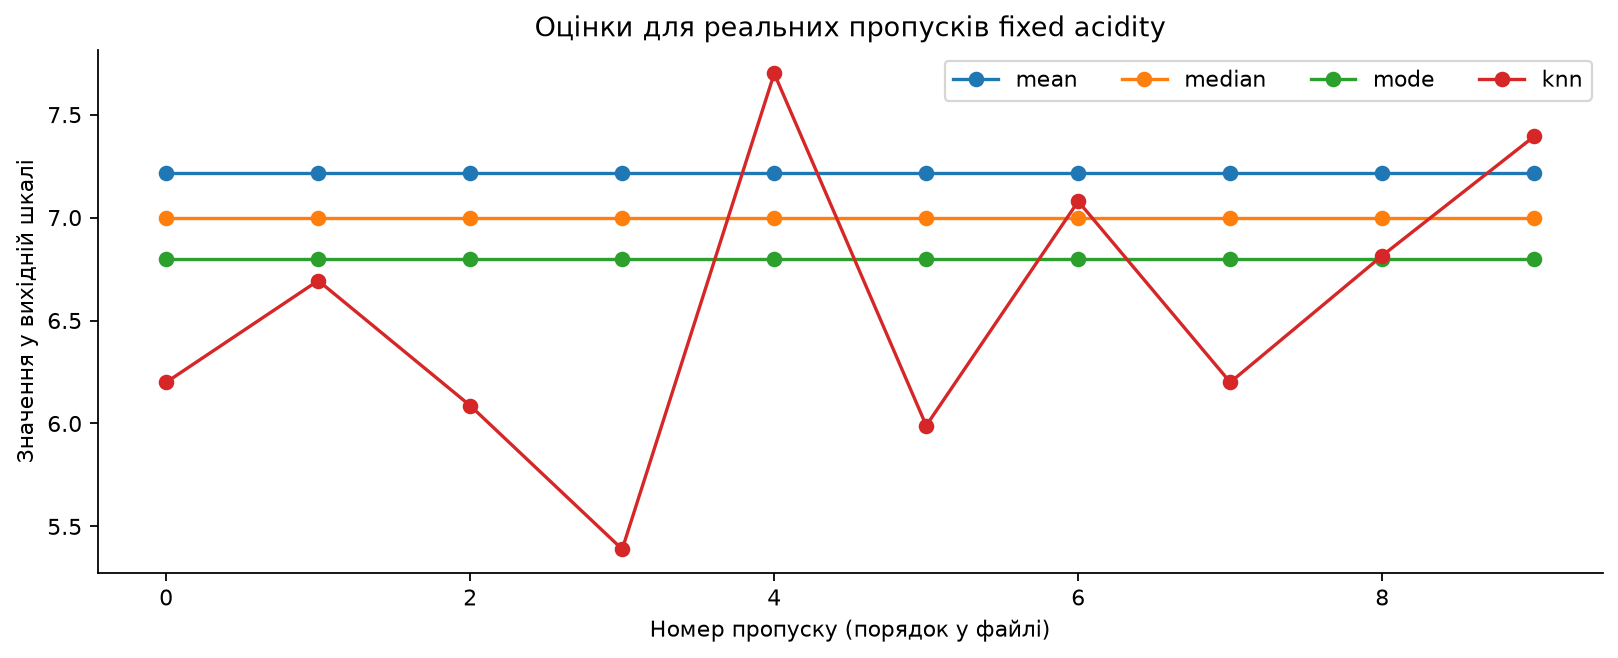

In [9]:
df, imputed_versions, validation, ranking, paths, summary = run_data_experiment()
display(ranking.rename("Середня стандартизована MAE"))
print("Найменша похибка у цьому експерименті:", summary["selected_imputation"])
print("Реальних пропусків до / після:", summary["missing_before"], "/", summary["missing_after"])
for path in paths[:2]:
    display(Image(filename=str(path)))

### Нормалізація
Застосовано й збережено три варіанти для результату обраного методу заповнення:

1. **MinMax:** $(x-x_{min})/(x_{max}-x_{min})$. На цих даних дає інтервал [0, 1], але залежить від екстремумів.
2. **Z-score:** $(x-\mu)/\sigma$. Вирівнює масштаби через середнє і стандартне відхилення.
3. **Robust:** $(x-\mathrm{median})/(Q_3-Q_1)$. Обраний основним для описового аналізу через асиметрію та крайні значення фізико-хімічних ознак.

Robust не обрізає крайні значення, не робить розподіл нормальним і не обмежує його інтервалом [0, 1]. Об’єктивно «найкращий» скейлер залежить від подальшої моделі, яку ця лабораторна не задає. Після оцінки методів фінальні перетворення навчаються на всьому наборі для описового аналізу. Для прогнозування їх потрібно заново навчати лише на train-вибірці.

chlorides               5.399849
sulphates               1.798467
fixed acidity           1.722805
volatile acidity        1.495512
residual sugar          1.435000
free sulfur dioxide     1.220066
alcohol                 0.565718
density                 0.503602
citric acid             0.473032
pH                      0.386966
total sulfur dioxide   -0.001177
Name: Асиметрія, dtype: float64

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,0.000000,-0.117647,0.357143,2.809524,-0.074074,0.666667,0.658228,1.313978,-1.000000,-0.352941,-0.833333,6
1,white,-0.538462,0.058824,0.214286,-0.222222,0.074074,-0.625000,0.177215,-0.191398,0.428571,-0.117647,-0.444444,6
2,white,0.846154,-0.058824,0.642857,0.619048,0.111111,0.041667,-0.265823,0.045161,0.238095,-0.411765,-0.111111,6
3,white,0.153846,-0.352941,0.071429,0.873016,0.407407,0.750000,0.860759,0.152688,-0.095238,-0.647059,-0.222222,6
4,white,0.153846,-0.352941,0.071429,0.873016,0.407407,0.750000,0.860759,0.152688,-0.095238,-0.647059,-0.222222,6


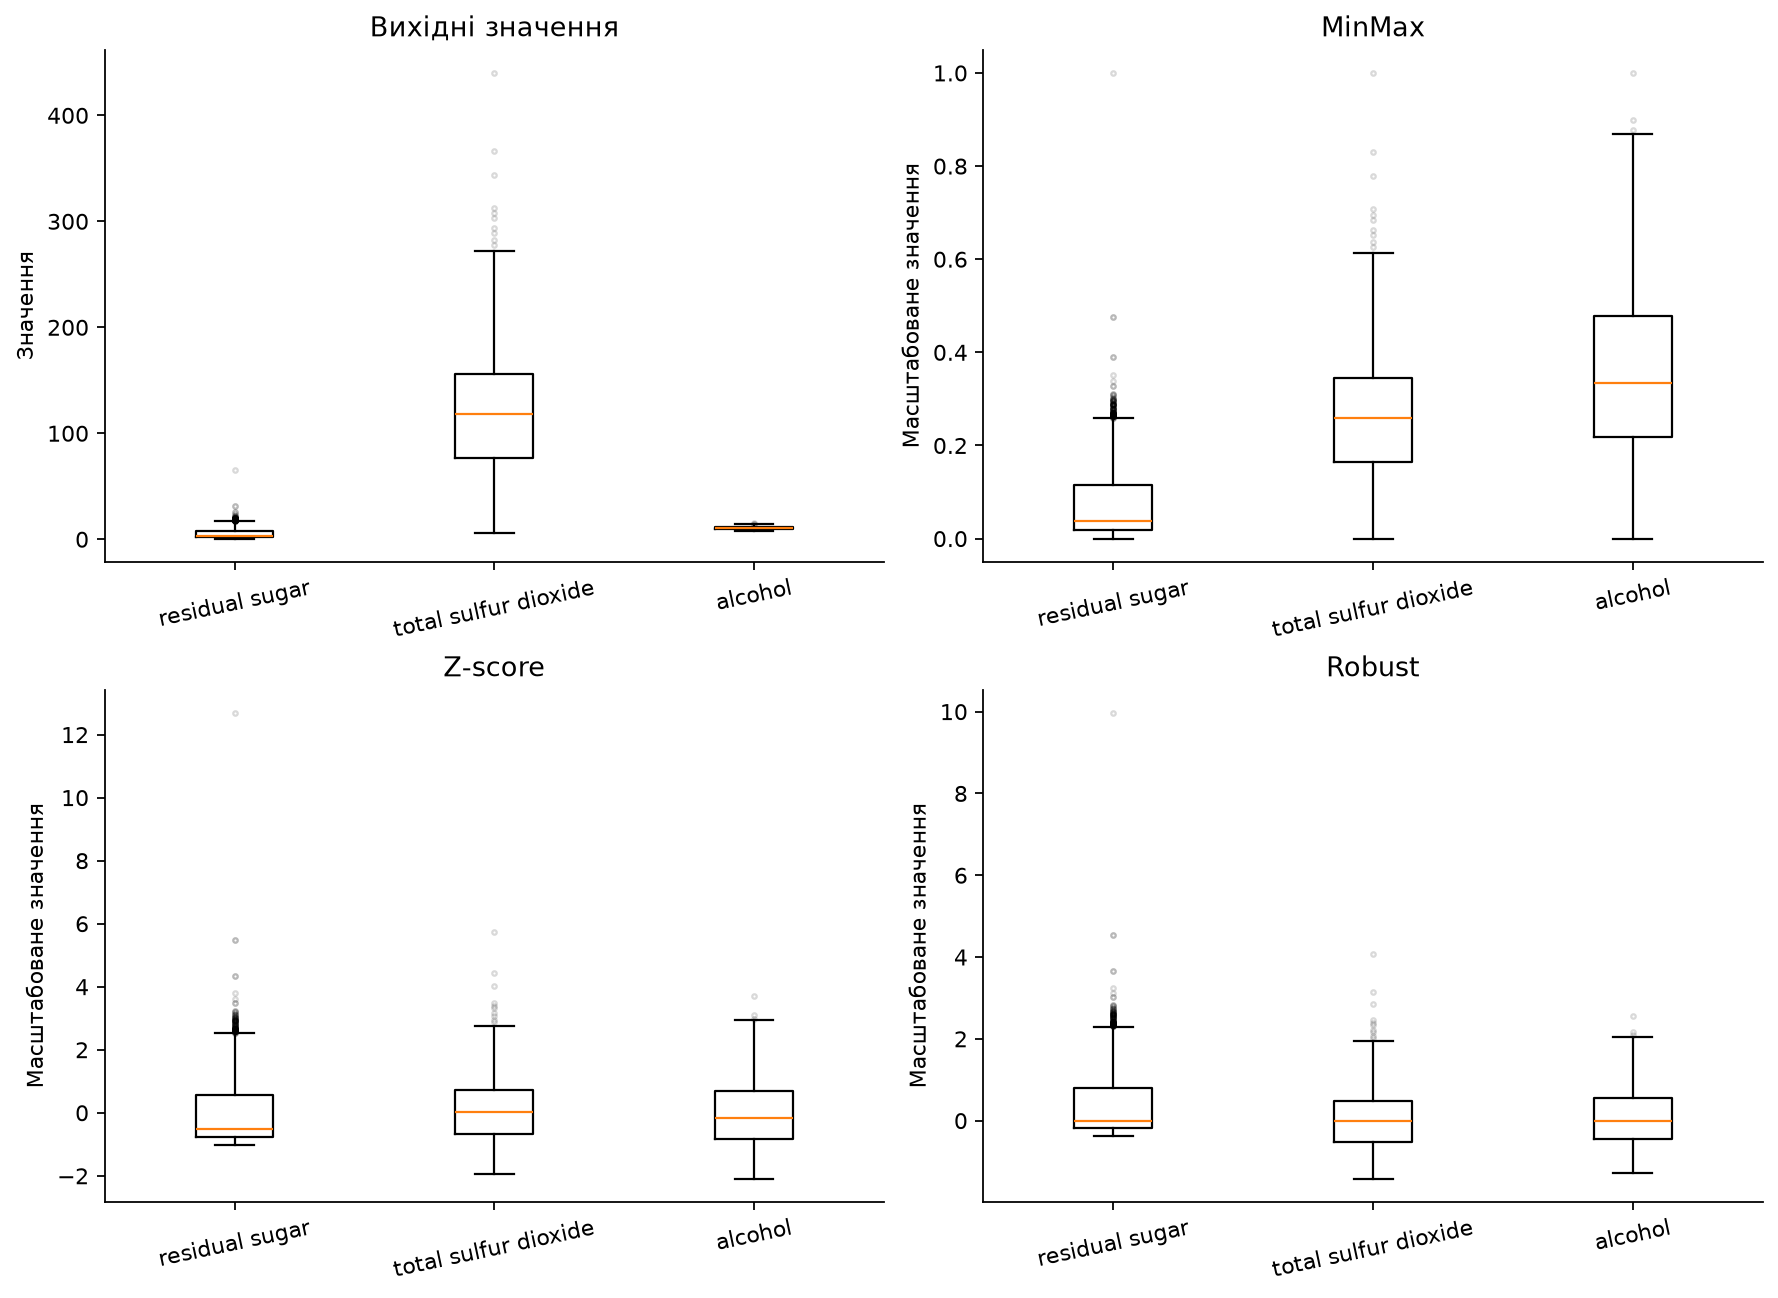

In [10]:
chosen = imputed_versions[summary["selected_imputation"]]
display(df[FEATURES].skew().sort_values(ascending=False).rename("Асиметрія"))
normalized = normalize_data(chosen, "robust")
display(normalized.head())
display(Image(filename=str(paths[2])))
assert not normalized.isna().any().any()
assert normalized["quality"].equals(df["quality"])
assert normalized["type"].equals(df["type"])

### NumPy: перевірка формули масштабування
Матриця `X` має форму «спостереження × числові ознаки». Віднімання вектора медіан та ділення на вектор міжквартильних розмахів використовує broadcasting. Ця комірка пов’язує виконаний аналіз із наданим матеріалом з NumPy.

In [11]:
X = chosen[FEATURES].to_numpy(dtype=float)
median = np.median(X, axis=0)
iqr = np.percentile(X, 75, axis=0) - np.percentile(X, 25, axis=0)
manual = (X - median) / np.where(iqr == 0, 1, iqr)
np.testing.assert_allclose(manual, normalized[FEATURES].to_numpy(), atol=1e-10)
print("Форма матриці:", X.shape)
print("Формула NumPy збігається з RobustScaler.")

Форма матриці: (6497, 11)
Формула NumPy збігається з RobustScaler.


## Висновки
Отримано текст двох вебсторінок без HTML-тегів і збережено реальну відповідь API у JSON. Реалізовано пошук погоди за датою в двох форматах, побудовано та збережено графіки. На справжньому датасеті Kaggle порівняно mean, median, mode та KNN, а також три способи масштабування. Нижче — фактично обчислений підсумок.

In [12]:
print(f"Датасет: {summary["rows"]} рядків, {summary["columns"]} стовпців.")
print(f"Заповнено {summary["missing_before"]} реальних пропусків.")
print(f"Обраний метод у контрольному експерименті: {summary["selected_imputation"]}.")
print("Основний масштабований результат: outputs/wine_normalized_robust.csv")
print("Усі показники похибки: outputs/imputation_validation.csv")
print("Графіки:")
for path in sorted((ROOT / "figures").glob("*.png")):
    print(" -", path.name)

Датасет: 6497 рядків, 13 стовпців.
Заповнено 38 реальних пропусків.
Обраний метод у контрольному експерименті: knn.
Основний масштабований результат: outputs/wine_normalized_robust.csv
Усі показники похибки: outputs/imputation_validation.csv
Графіки:
 - imputation_comparison.png
 - imputed_values.png
 - normalization_comparison.png
 - weather_coverage.png
 - weather_distribution.png
 - weather_temperature.png


## Джерела
- [Оригінальне завдання](https://github.com/maxvonlancaster/ida-labs/blob/main/assignement-1.ipynb).
- [Візуалізація даних](https://github.com/maxvonlancaster/intelligent-data-analysis/blob/main/src/103-data-visualization.ipynb).
- [Лінійна алгебра та NumPy](https://github.com/maxvonlancaster/intelligent-data-analysis/blob/main/src/104-linear-algebra.ipynb).
- [Kaggle: Data Cleaning — Feature Imputation](https://www.kaggle.com/datasets/ilayaraja07/data-cleaning-feature-imputation).
- Адреси вебсторінок та API, час отримання: `outputs/collection_sources.json`.